# Training curves from `.qlog` files

Parses every `logs/train_*.qlog` run, selects the run with the lowest validation loss for each model architecture, and plots only those winning runs.

In [33]:
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

LOGS_DIR = Path("..") / "logs"

EPOCH_RE = re.compile(
    r"epoch\s+(\d+)\s*\|\s*"
    r"train loss\s+(nan|[\d.]+)\s+mae\s+(nan|[\d.]+)\s+r2\s+(nan|-?[\d.]+).*?\|\s*"
    r"val loss\s+(nan|[\d.]+)\s+mae\s+(nan|[\d.]+)\s+r2\s+(nan|-?[\d.]+)"
)


def parse_qlog(path: Path) -> pd.DataFrame:
    rows = []
    for line in path.read_text().splitlines():
        match = EPOCH_RE.search(line)
        if not match:
            continue
        epoch, train_loss, train_mae, train_r2, val_loss, val_mae, val_r2 = match.groups()
        rows.append(
            {
                "epoch": int(epoch),
                "train_loss": float(train_loss),
                "train_mae": float(train_mae),
                "train_r2": float(train_r2),
                "val_loss": float(val_loss),
                "val_mae": float(val_mae),
                "val_r2": float(val_r2),
            }
        )
    return pd.DataFrame(rows)

In [34]:
qlog_paths = sorted(LOGS_DIR.glob("train_*.qlog"))

candidates = {}
for path in qlog_paths:
    model_name = path.name.split(".")[0].removeprefix("train_")
    df = parse_qlog(path)
    if df.empty:
        print(f"no epoch lines found in {path.name}, skipping")
        continue
    candidates.setdefault(model_name, []).append((path, df))

runs = {}
selected_paths = {}
for model_name, model_runs in sorted(candidates.items()):
    path, df = min(model_runs, key=lambda run: run[1]["val_loss"].min())
    runs[model_name] = df
    selected_paths[model_name] = path
    best = df.loc[df["val_loss"].idxmin()]
    print(
        f"{model_name}: selected {path.name} from {len(model_runs)} run(s); "
        f"best val loss {best['val_loss']:.4f} at epoch {int(best['epoch'])}"
    )

CNN: selected train_CNN.6854039.qlog from 4 run(s); best val loss 0.0195 at epoch 28
CNN_LSTM: selected train_CNN_LSTM.6848858.qlog from 2 run(s); best val loss 0.0204 at epoch 14
LSTM: selected train_LSTM.6788522.qlog from 3 run(s); best val loss 0.0209 at epoch 32
ResNet: selected train_ResNet.6860201.qlog from 1 run(s); best val loss 0.0216 at epoch 20
ViT: selected train_ViT.6848860.qlog from 2 run(s); best val loss 0.0220 at epoch 11
transformer: selected train_transformer.6848856.qlog from 2 run(s); best val loss 0.0211 at epoch 16


## Train vs. val loss per model

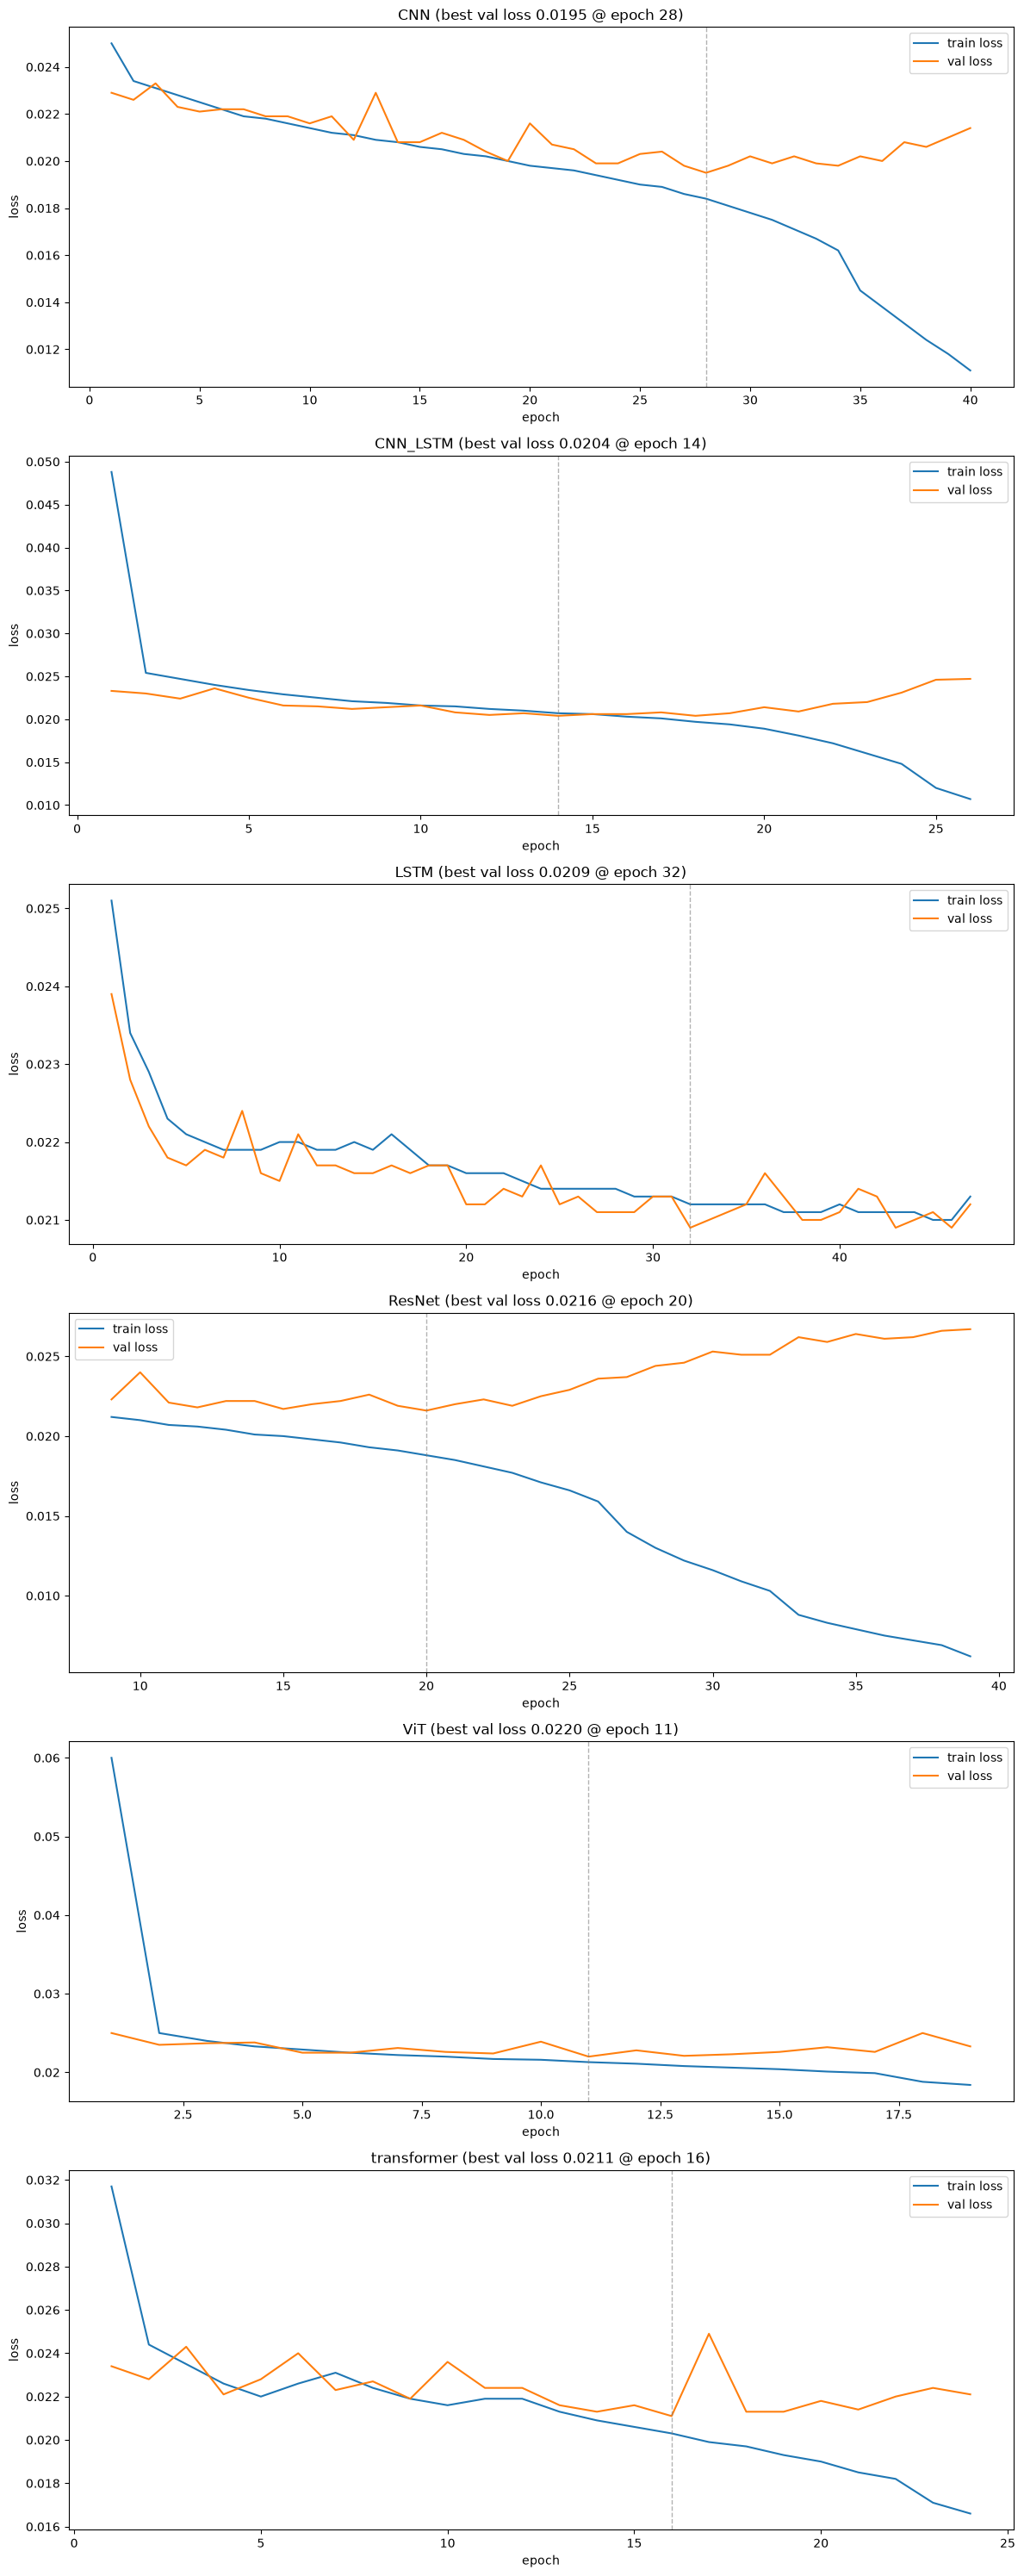

In [35]:
fig, axes = plt.subplots(len(runs), 1, figsize=(12, 5 * len(runs)), squeeze=False)

for ax, (model_name, df) in zip(axes[:, 0], runs.items()):
    ax.plot(df["epoch"], df["train_loss"], label="train loss")
    ax.plot(df["epoch"], df["val_loss"], label="val loss")
    best_epoch = df.loc[df["val_loss"].idxmin()]
    ax.axvline(best_epoch["epoch"], color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.set_title(f"{model_name} (best val loss {best_epoch['val_loss']:.4f} @ epoch {int(best_epoch['epoch'])})")
    ax.set_xlabel("epoch")
    ax.set_ylabel("loss")
    ax.legend()

fig.tight_layout()
plt.show()

## Val loss comparison across models

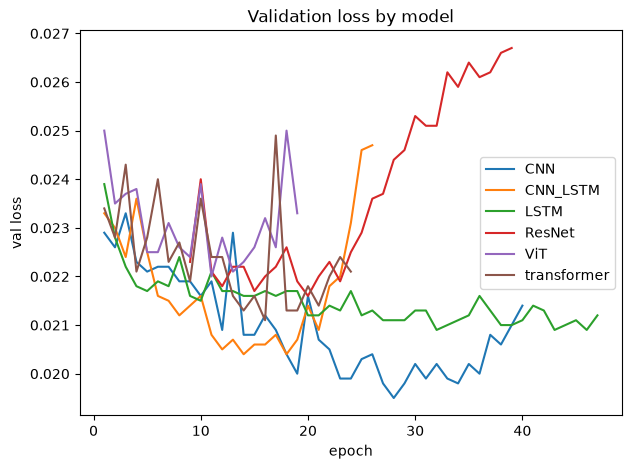

In [36]:
fig, ax = plt.subplots(figsize=(7, 5))

for model_name, df in runs.items():
    ax.plot(df["epoch"], df["val_loss"], label=model_name)

ax.set_xlabel("epoch")
ax.set_ylabel("val loss")
ax.set_title("Validation loss by model")
ax.legend()
plt.show()